# Variant effects with Borzoi

This notebook shows embpy's lower-level genomics API for sequence-to-function variant-effect work with [Borzoi](https://www.nature.com/articles/s41588-024-02053-6) (Linder et al. 2025, *Nat. Genet.*).

## What this notebook demonstrates

1. **Predicted profiles as an optional extra output.** `BorzoiWrapper.embed()` returns a pooled embedding by default, exactly like every other DNA model wrapper in embpy. Passing `return_profile=True` additionally runs Borzoi's prediction head and returns the full per-track, per-bin coverage profile (RNA-seq / ATAC / ChIP), the same output the Borzoi paper use for variant-effect analysis.
2. **`SNPEmbedder` with ref/alt as the default output.** `embed_snp()` always returns the reference and alternate-allele embeddings. Delta vectors (`alt - ref`) are computed by default too, but can be turned off (`compute_delta=False`), and a concatenated `[ref, alt]` feature vector is available on request (`compute_concat=True`).
3. **Profile-based variant-effect prediction.** `SNPEmbedder.predict_variant_effect()` implements the gene-level statistic from the Borzoi paper: sum the predicted (unsquashed) coverage over a gene's exon-overlapping bins for both alleles, then report the log2 fold-change per track.

This notebook uses the lower-level `embpy.models.dna_models.BorzoiWrapper` and `embpy.tl.genomics` API directly rather than the high-level `BioEmbedder`, since variant-effect prediction works on raw genomic coordinates rather than gene/protein identifiers.

**Compute note:** Borzoi's receptive field is 524,288 bp; a forward pass is a few GB of activations and is comfortably faster on GPU. `device="auto"` below will use CUDA if available and fall back to CPU otherwise (slow but correct).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from embpy.models.dna_models import BorzoiWrapper
from embpy.tl.genomics import (
    SNPContext,
    SNPEmbedder,
    SequenceProvider,
    genomic_to_bin_indices,
)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Load Borzoi

`borzoi_v0` (`johahi/borzoi-replicate-0`) is one of four published replicate folds; any of the `borzoi_v*` / `flashzoi_v*` entries in the DNA registry work the same way. Loading downloads the ~/.cache'd Hugging Face checkpoint on first use.

In [2]:
wrapper = BorzoiWrapper("johahi/borzoi-replicate-0")
wrapper.load(device)
print(f"Loaded {wrapper.model_name} | trunk dim = {wrapper.TRUNK_OUTPUT_DIM} | bin size = {wrapper.BIN_SIZE} bp")

Loaded johahi/borzoi-replicate-0 | trunk dim = 1536 | bin size = 32 bp


## 1. Predicted profiles as an optional extra output

We center a window on a well-studied *cis*-regulatory region (the *SORT1* locus on chr1, harboring the lipid-trait variant rs12740374) and pad/crop it to Borzoi's exact 524,288 bp input length so the profile's bin coordinates line up exactly with genomic coordinates -- this matters later for variant-effect aggregation.

`embed()` behaves like every other wrapper by default (returns only the pooled embedding). Passing `return_profile=True` additionally returns the raw per-track, per-bin coverage profile from `predict_profile()`.

In [3]:
CHROM = "chr1"
VARIANT_POS = 109_274_968   # rs12740374, SORT1 locus (GRCh38; verified via Ensembl REST variation lookup)
REF, ALT = "G", "T"

provider = SequenceProvider()  # falls back to the Ensembl REST API; pass fasta_dir=... for local genomes
window, snp_offset = provider.get_window(CHROM, VARIANT_POS, context=BorzoiWrapper.SEQUENCE_LENGTH)
window_start = VARIANT_POS - snp_offset  # 0-based genomic coordinate of window[0]
print(f"Window length: {len(window)} bp | variant at offset {snp_offset} | window_start={window_start}")

Window length: 524288 bp | variant at offset 262145 | window_start=109012823


In [4]:
embedding = wrapper.embed(window, pooling_strategy="mean")
embedding, profile = wrapper.embed(window, pooling_strategy="mean", return_profile=True)

print(f"Pooled embedding shape: {embedding.shape}")
print(f"Profile shape: {profile.shape}  (num_tracks, num_bins)")

track_meta = BorzoiWrapper.get_track_metadata()
display(track_meta[["identifier", "description"]].head())

Pooled embedding shape: (1536,)
Profile shape: (7611, 6144)  (num_tracks, num_bins)


,identifier,description
0,CNhs10608+,CAGE:Clontech Human Universal Reference Total ...
1,CNhs10608-,CAGE:Clontech Human Universal Reference Total ...
2,CNhs10610+,CAGE:SABiosciences XpressRef Human Universal T...
3,CNhs10610-,CAGE:SABiosciences XpressRef Human Universal T...
4,CNhs10612+,CAGE:Universal RNA - Human Normal Tissues Bioc...


Each row of `profile` is one experimental track (RNA-seq, ATAC, ChIP, ...); each column is a 32 bp genomic bin. Let's plot a couple of RNA-seq tracks around the variant to sanity-check the prediction looks like real coverage.

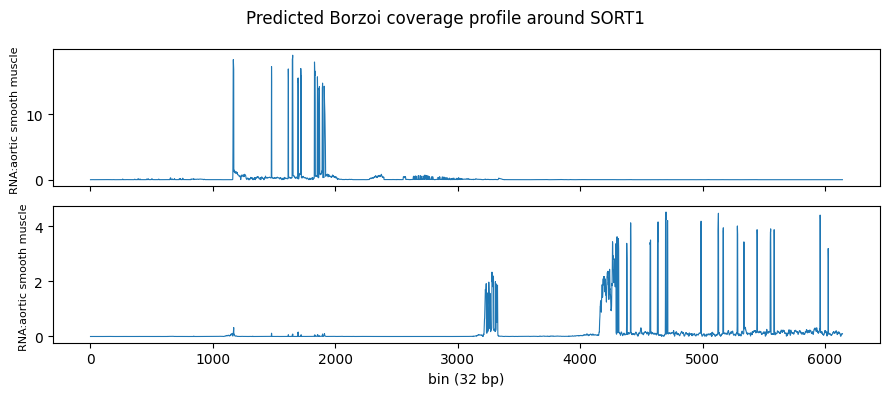

In [5]:
import matplotlib.pyplot as plt

# Track "identifier" is a raw file accession (e.g. "ENCFF281BWX+"); the
# human-readable assay/tissue lives in "description" as "ASSAY:detail".
rna_tracks = track_meta[track_meta["description"].str.startswith("RNA:")].head(2)
assert len(rna_tracks) > 0, "no RNA tracks found in track metadata"

fig, axes = plt.subplots(len(rna_tracks), 1, figsize=(9, 4), sharex=True, squeeze=False)
for ax, (track_idx, row) in zip(axes[:, 0], rna_tracks.iterrows()):
    ax.plot(profile[track_idx], lw=0.8)
    ax.set_ylabel(row["description"][:25], fontsize=8)
axes[-1, 0].set_xlabel("bin (32 bp)")
fig.suptitle("Predicted Borzoi coverage profile around SORT1")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "borzoi_profile_example.png", dpi=120)
plt.show()

## 2. `SNPEmbedder`: ref/alt by default, delta and concat on request

`SNPEmbedder.embed_snp()` always returns `ref_embedding` and `alt_embeddings` (one per alt allele). `delta_embeddings`/`delta_norms` are computed by default, but can be skipped with `compute_delta=False`; a concatenated `[ref, alt]` feature vector is available on request via `compute_concat=True`.

In [6]:
snp = SNPContext(
    chrom=CHROM,
    position=snp_offset,  # position relative to `window`, NOT the absolute genomic coordinate
    ref_allele=REF,
    alt_alleles=[ALT],
    context_window=BorzoiWrapper.SEQUENCE_LENGTH,
    strand="+",
    variant_id="rs12740374",
)

embedder = SNPEmbedder(wrapper, pooling_strategy="mean")

# Default: ref + alt + delta, no concat.
result = embedder.embed_snp(snp, chromosome_sequence=window)
print("ref_embedding:", result.ref_embedding.shape)
print("alt_embeddings:", [a.shape for a in result.alt_embeddings])
print("delta_embeddings (default on):", [d.shape for d in result.delta_embeddings])
print("concat_embeddings (default off):", result.concat_embeddings)

# Skip delta, request concat instead.
result_concat = embedder.embed_snp(
    snp, chromosome_sequence=window, compute_delta=False, compute_concat=True
)
print()
print("compute_delta=False ->", result_concat.delta_embeddings)
print("compute_concat=True ->", [c.shape for c in result_concat.concat_embeddings])

ref_embedding: (1536,)
alt_embeddings: [(1536,)]
delta_embeddings (default on): []
concat_embeddings (default off): []



compute_delta=False -> []
compute_concat=True -> [(3072,)]


## 3. Profile-based variant-effect prediction (Borzoi-style)

The Borzoi paper score a variant's effect on a gene by summing the model's predicted (linear-scale) coverage over the gene's exon-overlapping bins for the reference and alternate alleles, then reporting the log2 fold-change with a pseudocount. `SNPEmbedder.predict_variant_effect()` implements exactly this, generically for any model wrapper exposing `predict_profile()`.

`genomic_to_bin_indices()` converts genomic exon coordinates into the bin indices `predict_variant_effect` aggregates over. For *SORT1*, we use its annotated exon span; in a real workflow these would come from a GTF or `GeneResolver.get_gene_regions(...)`.

In [7]:
# Real SORT1 (GRCh38, chr1, ENST00000256637) exons near the variant, fetched once via
# the Ensembl REST API (https://rest.ensembl.org/overlap/id/ENSG00000134243?feature=exon);
# in practice use GeneResolver.get_gene_regions("SORT1", region="exons") or a GTF file.
sort1_exons = [
    (109_309_575, 109_314_057),
    (109_314_261, 109_314_384),
    (109_314_672, 109_314_778),
]

bin_indices = genomic_to_bin_indices(
    sort1_exons,
    window_start=window_start,
    bin_size=wrapper.BIN_SIZE,
    profile_offset_bp=wrapper.profile_offset_bp,
    num_bins=profile.shape[1],
)
print(f"{len(bin_indices)} bins overlap the SORT1 exon used here.")

vep_result = embedder.predict_variant_effect(
    snp,
    chromosome_sequence=window,
    bin_indices=bin_indices,
    undo_squashed_scale=True,  # required: the statistic assumes linear-scale coverage
)

print(f"Reference profile shape: {vep_result.ref_profile.shape}")
print(f"Effect scores (per track) for alt '{ALT}': {vep_result.effect_scores[0].shape}")

top_hits = vep_result.top_tracks(alt_index=0, n=10)
pd.DataFrame(top_hits, columns=["track", "log2_fold_change"])

151 bins overlap the SORT1 exon used here.


Reference profile shape: (7611, 6144)
Effect scores (per track) for alt 'T': (7611,)


,track,log2_fold_change
0,ENCFF611FWS,1.467083
1,ENCFF746CXV,1.463224
2,ENCFF893KHE,1.435684
3,ENCFF837FTN,1.370417
4,ENCFF623CXL,-1.361386
5,ENCFF360QQU,1.340232
6,ENCFF301WTK,-1.280393
7,ENCFF891SNS,1.252314
8,ENCFF905FLR,1.175283
9,ENCFF107LVE,1.071769


The tracks at the top of this table are Borzoi's prediction of which assays (cell types / RNA-seq vs ATAC vs ChIP) are most affected by the variant at the *SORT1* locus.